# Chapter 3: Relationships Between Variables

Topics covered:
1. Covariance (intuition)
2. Pearson Correlation
3. Scatter Plots
4. Spearman Correlation
5. Kendall's Tau (optional)
6. Correlation Matrices
7. QQ Plots
8. Odds & Odds Ratios
9. Contingency Tables

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')
print('Ready.')

Ready.


---
## 1. Covariance

### Task 1 — Compute covariance by hand

You have the following data for 5 students:

| Student | Hours studied (X) | Exam score (Y) |
|---------|-------------------|----------------|
| A       | 1                 | 50             |
| B       | 2                 | 60             |
| C       | 3                 | 65             |
| D       | 4                 | 80             |
| E       | 5                 | 90             |

**Do the following using only numpy (no `np.cov`):**
1. Compute the mean of X and the mean of Y
2. Compute each deviation: `(xi - x_mean)` and `(yi - y_mean)`
3. Multiply the deviations element-wise
4. Sum them up and divide by `n - 1` to get the sample covariance
5. Print the result

In [11]:
X = [1,2,3,4,5]
Y = [50,60,65,80,90]
x_mean = np.mean(X)
y_mean = np.mean(Y)
x_dev = np.subtract(X,x_mean)
y_dev = np.subtract(Y,y_mean)
xy_multiplied = np.multiply(x_dev,y_dev)
xy_sum = np.sum(xy_multiplied)
xy_mean = xy_sum / (5-1)
print(xy_mean)

25.0


### Task 2 — Verify with numpy

Use `np.cov()` on the same data to verify your result from Task 1.

- Note: `np.cov()` returns a 2×2 matrix. Which cell contains Cov(X, Y)?
- What are the other two cells? Why does that make sense?

In [ ]:
# your code here
np.cov(X,Y)

### Task 3 — Sign of covariance

Below are three pairs of arrays. **Before running any code**, predict whether the covariance will be positive, negative, or near zero. Then compute and check.

```python
X1 = [1, 2, 3, 4, 5]
Y1 = [5, 4, 3, 2, 1]   # prediction: ?

X2 = [1, 2, 3, 4, 5]
Y2 = [3, 3, 3, 3, 3]   # prediction: ?

X3 = [1, 2, 3, 4, 5]
Y3 = [2, 4, 1, 5, 3]   # prediction: ?
```

Write your predictions as comments, then compute all three covariances.

In [ ]:
X = [1,2,3,4,5]
Y = [5,4,3,2,1]
cov_xy = np.cov(X,Y)
print(cov_xy)

### Task 4 — Scale dependence

This task demonstrates why covariance magnitude is hard to interpret.

Use this data (height and weight of 6 people):

```python
height_cm = [160, 165, 170, 175, 180, 185]
weight_kg = [55,  60,  68,  72,  80,  85]
```

1. Compute `Cov(height_cm, weight_kg)`
2. Convert height to meters: `height_m = height_cm / 100`
3. Compute `Cov(height_m, weight_kg)`
4. Print both values. The relationship is identical — how different are the numbers?
5. What does this tell you about interpreting raw covariance?

In [ ]:
heights = [160, 165, 170, 175, 180, 185]
weights = [55,  60,  68,  72,  80,  85]
cov_height_weight = np.cov(heights,weights)
print(cov_height_weight)
height_m = np.divide(heights,100)
cov_height_m_weight = np.cov(height_m,weights)
print(cov_height_m_weight)

---
## 2. Pearson Correlation

### Demo — Four datasets, four stories

Below are four pre-built datasets that each tell a different story about linearity.
Run this cell as-is — read the code, understand what each dataset represents, then study the plots and correlations carefully.

| Dataset | What it represents |
|---------|--------------------|
| A | Clean positive linear relationship |
| B | Curved (quadratic) relationship |
| C | Perfect linear relationship with one outlier |
| D | No relationship (pure noise) |

In [ ]:
np.random.seed(42)
x = np.linspace(1, 10, 50)

# Dataset A: clean linear
y_a = 2 * x + np.random.normal(0, 1.5, 50)

# Dataset B: quadratic (curved)
y_b = (x - 5.5) ** 2 + np.random.normal(0, 0.5, 50)

# Dataset C: linear with one strong outlier
y_c = 2 * x + np.random.normal(0, 1.5, 50)
y_c[0] = 35   # inject outlier

# Dataset D: pure noise — no relationship
y_d = np.random.normal(0, 5, 50)

datasets = [
    (x, y_a, 'A — Linear'),
    (x, y_b, 'B — Quadratic'),
    (x, y_c, 'C — Linear + outlier'),
    (x, y_d, 'D — No relationship'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, (xi, yi, label) in zip(axes, datasets):
    r, p = stats.pearsonr(xi, yi)
    ax.scatter(xi, yi, alpha=0.7, edgecolors='white', linewidth=0.5)
    ax.set_title(f'{label}\nr = {r:.3f}  |  p = {p:.3f}', fontsize=12)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

plt.suptitle("Pearson r — Four datasets, four stories", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('media/pearson_four_datasets.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to media/')

### Task 5 — Compute Pearson r by hand

Using the same student data from Task 1:
```
X = [1, 2, 3, 4, 5]      (hours studied)
Y = [50, 60, 65, 80, 90]  (exam score)
```

Compute Pearson r **without using `scipy` or `np.corrcoef`**:
1. Reuse the covariance you computed in Task 1
2. Compute `std(X)` and `std(Y)` using `np.std(..., ddof=1)` (sample std)
3. Apply the formula: `r = Cov(X,Y) / (std_x * std_y)`
4. Print r — what does the value tell you about the relationship?

In [5]:
x = [1,2,3,4,5]
y = [50,60,65,80,90]
x_mean = np.mean(x)
y_mean = np.mean(y)
x_dev = np.subtract(x, x_mean)
y_dev = np.subtract(y, y_mean)
xy_multiplied = np.multiply(x_dev, y_dev)
xy_sum = np.sum(xy_multiplied) # nominator 

x_denom = np.sqrt(np.sum(np.square(x_dev)))
y_denom = np.sqrt(np.sum(np.square(y_dev)))
r = xy_sum / (x_denom * y_denom)
print(r)


0.9901475429766743


### Task 6 — Verify with scipy and confirm scale-independence

1. Use `stats.pearsonr(X, Y)` to verify your r from Task 5
2. Now recompute r using `height_cm` and `weight_kg` from Task 4, then using `height_m` and `weight_kg`
3. What do you notice compared to what happened with covariance?
4. Print all results with clear labels

In [8]:
R = stats.pearsonr(x,y)
print(R)

height_cm = [160, 165, 170, 175, 180, 185]
weight_kg = [55,  60,  68,  72,  80,  85]
R = stats.pearsonr(height_cm, weight_kg)
print(R)

height_m = np.divide(height_cm, 100)
R = stats.pearsonr(height_m, weight_kg)
print(R)


PearsonRResult(statistic=0.9901475429766742, pvalue=0.0011722164447169094)
PearsonRResult(statistic=0.9971300545245474, pvalue=1.2343061270263401e-05)
PearsonRResult(statistic=0.9971300545245475, pvalue=1.2343061270263401e-05)


### Task 7 — The r = 0 trap

This task shows that r = 0 does NOT mean "no relationship".

```python
X = np.linspace(-4, 4, 100)
Y = X ** 2
```

1. Compute Pearson r between X and Y
2. Plot the scatter plot
3. What is r? Does it match what you see in the plot?
4. Write a comment explaining why Pearson fails here

Pearson r: PearsonRResult(statistic=3.191891195797325e-16, pvalue=0.9999999999999979)


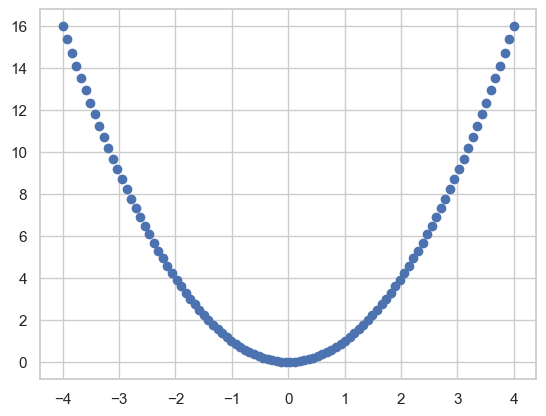

In [13]:
X = np.linspace(-4, 4, 100)
Y = X ** 2

R = stats.pearsonr(X,Y)
print('Pearson r:', R)

plt.scatter(X,Y)
plt.show()




### Task 8 — Effect of a single outlier

Start with a clean dataset:
```python
np.random.seed(0)
X = np.linspace(1, 10, 30)
Y = 3 * X + np.random.normal(0, 1, 30)
```

1. Compute and print r for the clean data
2. Add a single outlier: `X = np.append(X, 5)` and `Y = np.append(Y, 60)`
3. Recompute and print r
4. Plot both versions side by side (with and without outlier), showing r on each
5. How much did one point change the correlation?

In [ ]:
np.random.seed(0)
X = np.linspace(1, 10, 30)
Y = 3 * X + np.random.normal(0, 1, 30)

r = stats.pearsonr(X,Y)
print(r)

X = np.append(X, 5)
Y = np.append(Y, 60)
r = stats.pearsonr(X,Y)
print(r)

PearsonRResult(statistic=0.9910067830826544, pvalue=5.247752744026834e-26)
PearsonRResult(statistic=0.684363861485184, pvalue=2.1802681677178452e-05)


---
## 3. Scatter Plots

Scatter plots are the most important visualization for two continuous variables.
A correlation number alone can lie — the plot always tells the full story.

When reading a scatter plot, look for **five things**:
1. **Direction** — does it go up or down?
2. **Linearity** — is it a straight line or a curve?
3. **Strength** — are points tightly packed or scattered widely?
4. **Outliers** — any points far from the rest?
5. **Heteroscedasticity** — does the spread of Y grow as X increases (fan shape)?

### Demo — Six scatter plot patterns

Run this cell as-is. Study each plot carefully — learn to recognize each pattern by sight.
These are the six shapes you will encounter most often in real data.

| Pattern | What to look for |
|---------|-----------------|
| Strong positive linear | Tight band going up-right |
| Strong negative linear | Tight band going down-right |
| Weak / noisy linear | Wide cloud, slight trend visible |
| Non-linear (sine) | Wavy — r near 0 even though structure exists |
| Heteroscedasticity | Fan shape — spread grows with X |
| Two clusters | Looks like one group but is actually two |

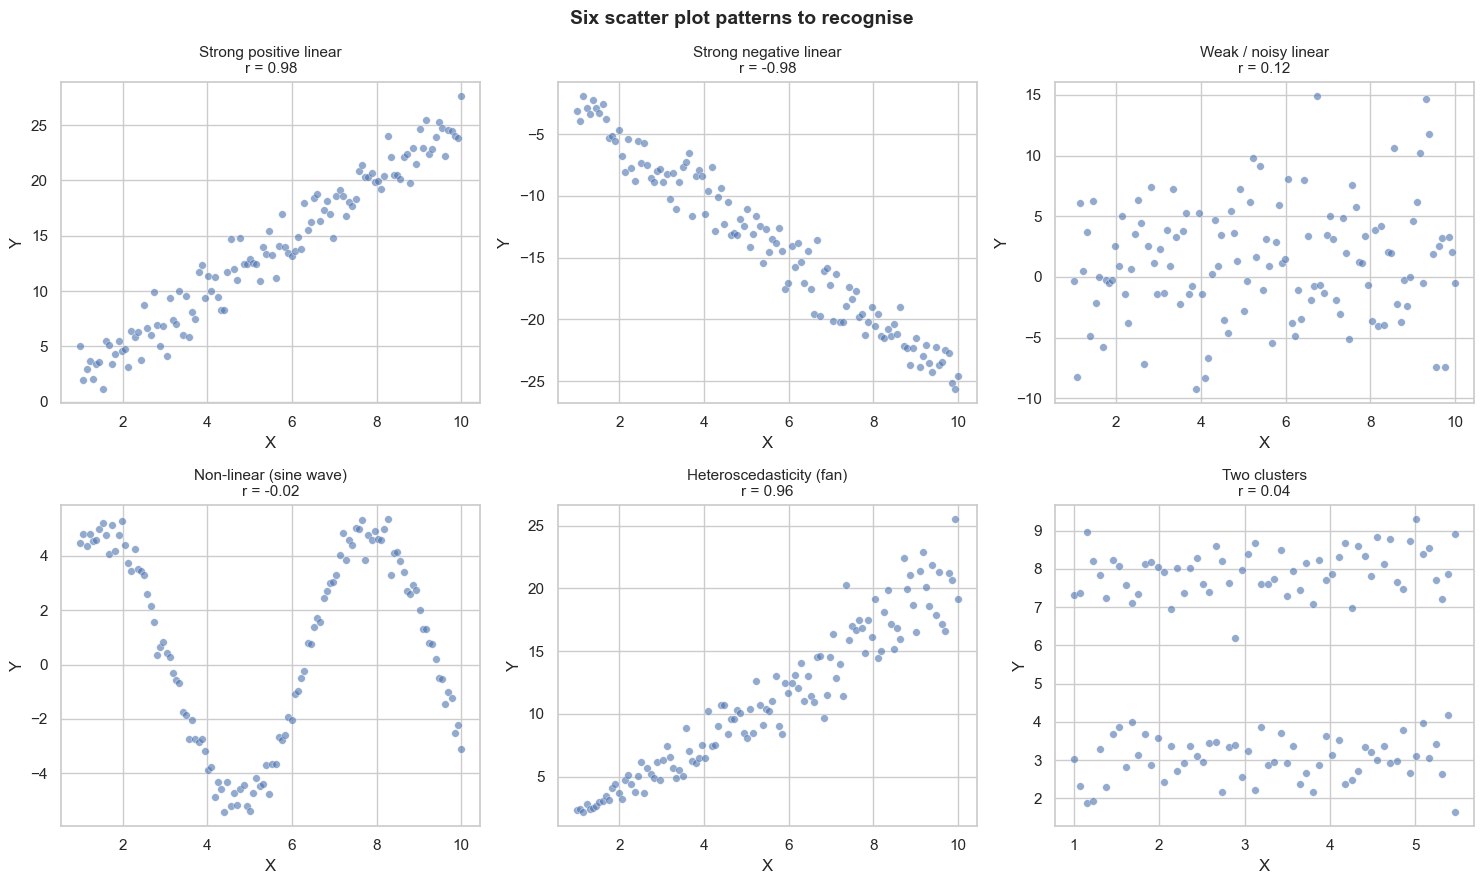

Saved to media/


In [ ]:
np.random.seed(7)
n = 120
x = np.linspace(1, 10, n)

patterns = [
    (x,  2.5 * x + np.random.normal(0, 1.5, n),                          'Strong positive linear'),
    (x, -2.5 * x + np.random.normal(0, 1.5, n),                          'Strong negative linear'),
    (x,  0.3 * x + np.random.normal(0, 4.5, n),                          'Weak / noisy linear'),
    (x,  np.sin(x) * 5 + np.random.normal(0, 0.4, n),                    'Non-linear (sine wave)'),
    (x,  2 * x + np.random.normal(0, 0.3 * x, n),                        'Heteroscedasticity (fan)'),
    (np.concatenate([x[:60], x[:60]]),
     np.concatenate([np.random.normal(3, 0.6, 60), np.random.normal(8, 0.6, 60)]),
                                                                           'Two clusters'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, (xi, yi, title) in zip(axes, patterns):
    r, _ = stats.pearsonr(xi, yi)
    ax.scatter(xi, yi, alpha=0.6, s=30, edgecolors='white', linewidth=0.4)
    ax.set_title(f'{title}\nr = {r:.2f}', fontsize=11)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

plt.suptitle('Six scatter plot patterns to recognise', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('media/scatter_six_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to media/')

### Demo — Scatter plots on real data (iris dataset)

Run this cell as-is. The same two variables are plotted twice — once plain, once colored by species.
Notice how color reveals structure that a plain scatter plot completely hides.

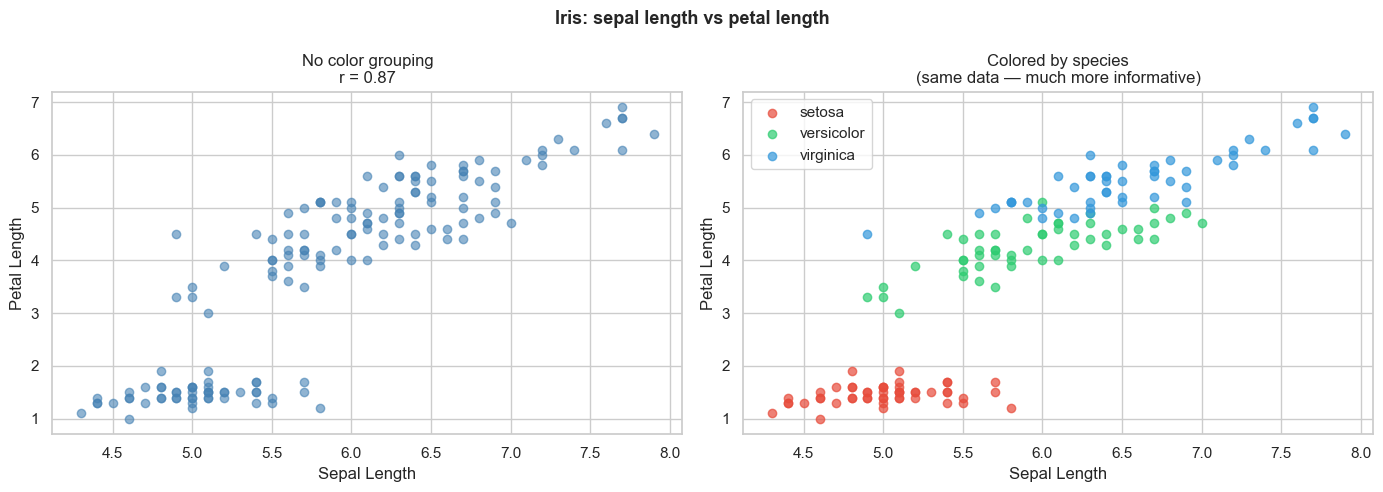

In [ ]:
iris = sns.load_dataset('iris')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: no color — you only see the aggregate trend
r_all, _ = stats.pearsonr(iris['sepal_length'], iris['petal_length'])
axes[0].scatter(iris['sepal_length'], iris['petal_length'], alpha=0.6, color='steelblue')
axes[0].set_title(f'No color grouping\nr = {r_all:.2f}', fontsize=12)
axes[0].set_xlabel('Sepal Length')
axes[0].set_ylabel('Petal Length')

# Right: colored by species — clusters become obvious
palette = {'setosa': '#e74c3c', 'versicolor': '#2ecc71', 'virginica': '#3498db'}
for species, group in iris.groupby('species'):
    axes[1].scatter(group['sepal_length'], group['petal_length'],
                    label=species, alpha=0.7, color=palette[species])
axes[1].set_title('Colored by species\n(same data — much more informative)', fontsize=12)
axes[1].set_xlabel('Sepal Length')
axes[1].set_ylabel('Petal Length')
axes[1].legend()

plt.suptitle('Iris: sepal length vs petal length', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('media/scatter_iris.png', dpi=150, bbox_inches='tight')
plt.show()

### Task 9 — Read and interpret a real scatter plot

Load the `tips` dataset:
```python
tips = sns.load_dataset('tips')
```
Columns: `total_bill`, `tip`, `sex`, `smoker`, `day`, `time`, `size`

1. Plot `total_bill` (x) vs `tip` (y) as a plain scatter
2. Compute Pearson r and show it in the title
3. Look carefully at the shape — is it linear? Do you see a fan (heteroscedasticity)?
4. Re-plot the same axes but color points by `smoker` (yes/no)
5. Does the pattern differ between smokers and non-smokers?
6. Write your interpretation as a comment below the plot

/var/folders/8c/0z32cvy11_b87z01prb1k7sh0000gn/T/ipykernel_53643/3509748903.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for smoker, group in tips.groupby('smoker'):


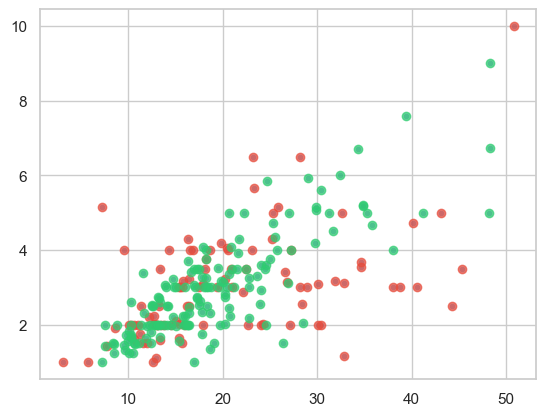

In [3]:
tips = sns.load_dataset('tips')
x = tips['total_bill']
y = tips['tip']


plt.scatter(x, y, alpha=0.6, s=20, edgecolors='white', linewidth=0.4)
palette = {'Yes': '#e74c3c', 'No': '#2ecc71'}
for smoker, group in tips.groupby('smoker'):
    plt.scatter(group['total_bill'], group['tip'],
                label=smoker, alpha=0.7, color=palette[smoker])
plt.show()

### Task 10 — Spot the hidden cluster

Using the iris dataset:

1. Plot `petal_length` (x) vs `petal_width` (y) — no color
2. Compute r — it will look strong and clean
3. Re-plot the same variables colored by `species`
4. What does the coloring reveal that the plain plot hid?
5. Compute r separately for each species and print them
6. How do the per-species r values compare to the overall r?

*Hint for step 5: `for species, group in iris.groupby('species')`*

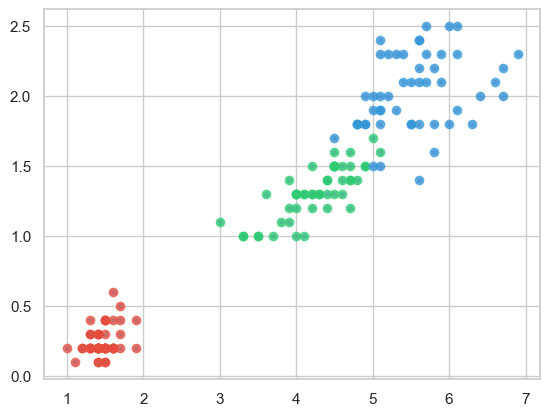

In [6]:
tips = sns.load_dataset('iris')
x = tips['petal_length']
y = tips['petal_width']


plt.scatter(x, y, alpha=0.6, s=20, edgecolors='white', linewidth=0.4)
palette = {'setosa': '#e74c3c', 'versicolor': '#2ecc71', 'virginica': '#3498db'}
for species, group in tips.groupby('species'):
    plt.scatter(group['petal_length'], group['petal_width'],
                label=species, alpha=0.7, color=palette[species])
plt.show()

---
## 4. Spearman Correlation

Spearman correlation measures the strength of a **monotonic** relationship.
It works by converting both variables to ranks, then computing Pearson on those ranks.

Key advantages over Pearson:
- Robust to outliers (an extreme value just becomes rank 1 or rank n)
- Works on ordinal data (rating scales, rankings)
- Catches monotonic but non-linear relationships
- No normality assumption required

### Demo — How ranking works and why it helps

Run this cell as-is. It shows the ranking process step by step, then compares Pearson vs Spearman on three datasets where they give very different answers.

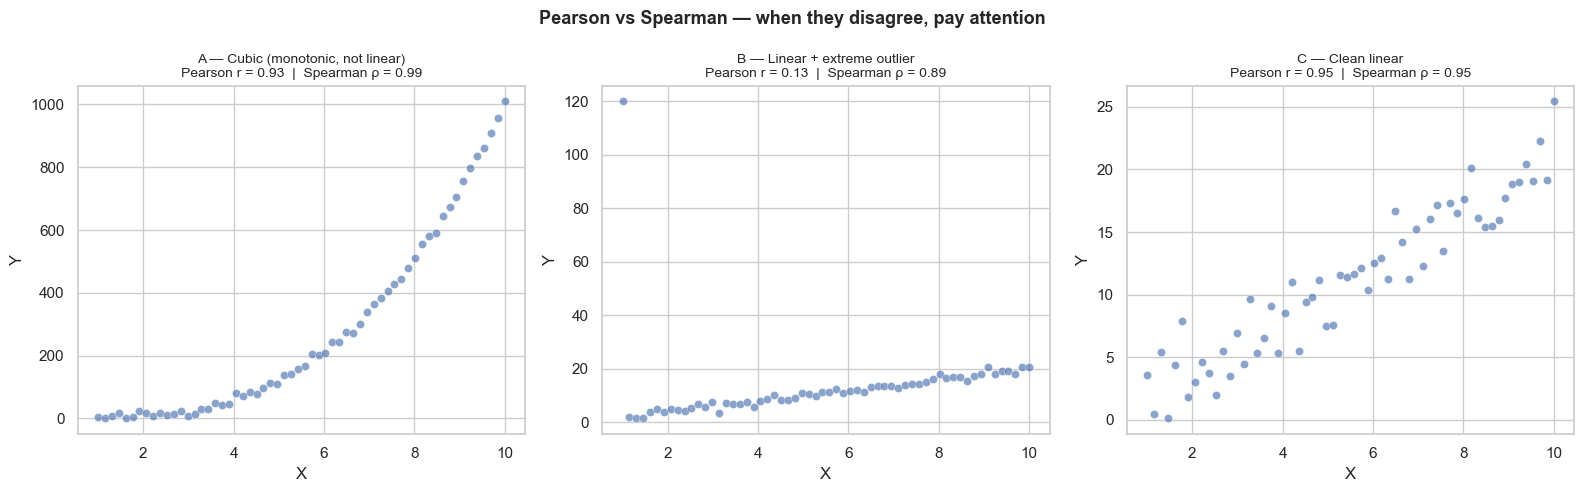

Saved to media/


In [9]:
np.random.seed(42)
x = np.linspace(1, 10, 60)

# Dataset A: monotonic but curved (cubic) — Spearman wins
y_a = x ** 3 + np.random.normal(0, 10, 60)

# Dataset B: linear with a heavy outlier — Spearman is more robust
y_b = 2 * x + np.random.normal(0, 1, 60)
y_b[0] = 120   # extreme outlier

# Dataset C: clean linear — both should agree
y_c = 2 * x + np.random.normal(0, 2, 60)

datasets = [
    (x, y_a, 'A — Cubic (monotonic, not linear)'),
    (x, y_b, 'B — Linear + extreme outlier'),
    (x, y_c, 'C — Clean linear'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (xi, yi, title) in zip(axes, datasets):
    pearson_r,  _ = stats.pearsonr(xi, yi)
    spearman_r, _ = stats.spearmanr(xi, yi)
    ax.scatter(xi, yi, alpha=0.65, s=35, edgecolors='white', linewidth=0.4)
    ax.set_title(f'{title}\nPearson r = {pearson_r:.2f}  |  Spearman ρ = {spearman_r:.2f}', fontsize=10)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

plt.suptitle('Pearson vs Spearman — when they disagree, pay attention', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('media/spearman_vs_pearson.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to media/')

### Task 12 — Rank by hand and compute Spearman manually

Use this small dataset:
```
X = [8, 3, 15, 1, 6]
Y = [42, 18, 95, 10, 30]
```

Do the following **without `stats.spearmanr()`**:
1. Rank X from smallest to largest (rank 1 = smallest). Store as `rank_x`
2. Rank Y the same way. Store as `rank_y`
3. Compute Pearson r between `rank_x` and `rank_y` using `stats.pearsonr()` — that is Spearman ρ
4. Verify your result with `stats.spearmanr(X, Y)`
5. Do the two match?

*Hint: `scipy.stats.rankdata()` ranks an array for you — but try doing it manually with `np.argsort()` first.*

In [10]:
X = [8, 3, 15, 1, 6]
Y = [42, 18, 95, 10, 30]
rank_x = [4,2,5,1,3]
rank_y = [4,2,5,1,3]
pearson_r, _ = stats.pearsonr(rank_x, rank_y)
print(pearson_r)
spearman_r, _ = stats.spearmanr(X, Y)
print(spearman_r)


1.0
0.9999999999999999


### Task 13 — Pearson vs Spearman on a monotonic curve

```python
np.random.seed(1)
X = np.linspace(0.1, 3, 80)
Y = np.log(X) + np.random.normal(0, 0.15, 80)   # log relationship — monotonic but not linear
```

1. Compute and print both Pearson r and Spearman ρ
2. Plot the scatter — does the relationship look linear or curved?
3. Which measure better captures what you see in the plot?
4. Add a comment explaining why Spearman handles this better than Pearson

0.9206823978884633
0.9688701359587436


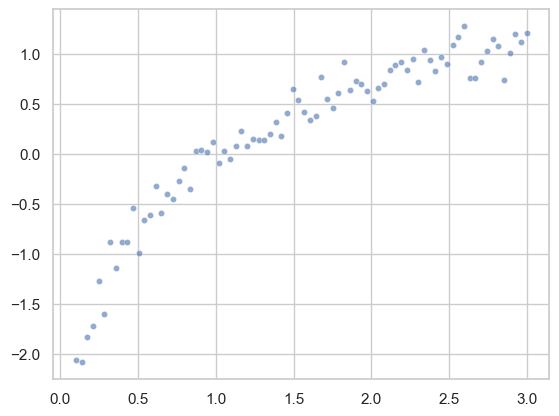

In [11]:
np.random.seed(1)
X = np.linspace(0.1, 3, 80)
Y = np.log(X) + np.random.normal(0, 0.15, 80)   # log relationship — monotonic but not linear

r_pearson, _ = stats.pearsonr(X, Y)
print(r_pearson)
r_spearman, _ = stats.spearmanr(X, Y)
print(r_spearman)

plt.scatter(X, Y, alpha=0.6, s=20, edgecolors='white', linewidth=0.4)
plt.show()

### Task 14 — Outlier robustness

This task shows why Spearman is more robust to outliers than Pearson.

```python
np.random.seed(3)
X = np.linspace(1, 10, 40)
Y = 2 * X + np.random.normal(0, 1.5, 40)
```

1. Compute Pearson r and Spearman ρ on the clean data — print both
2. Inject two extreme outliers:
   ```python
   X = np.append(X, [5, 5])
   Y = np.append(Y, [80, -40])
   ```
3. Recompute both measures — print them with clear labels
4. Plot clean vs contaminated side by side, showing both r values on each
5. Which measure shifted more? Why does ranking protect Spearman from this?

0.9602767546987667
0.9611632270168857
0.345110865077064
0.893804951910666


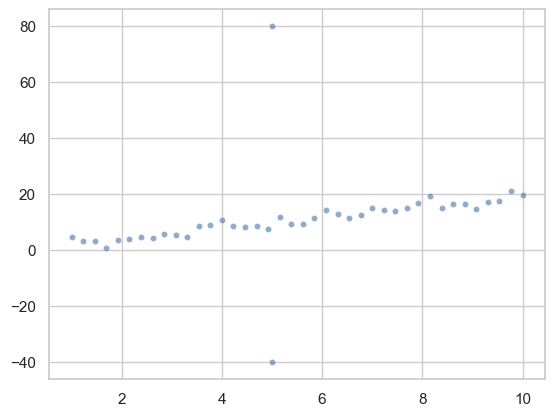

In [12]:
np.random.seed(3)
X = np.linspace(1, 10, 40)
Y = 2 * X + np.random.normal(0, 1.5, 40)
r_pearson, _ = stats.pearsonr(X, Y)
print(r_pearson)
r_spearman, _ = stats.spearmanr(X, Y)
print(r_spearman)

X = np.append(X, [5, 5])
Y = np.append(Y, [80, -40])

r_pearson, _ = stats.pearsonr(X, Y)
print(r_pearson)
r_spearman, _ = stats.spearmanr(X, Y)
print(r_spearman)

plt.scatter(X, Y, alpha=0.6, s=20, edgecolors='white', linewidth=0.4)
plt.show()

### Task 15 — Ordinal data (rating scales)

Spearman is the correct choice when your data is ordinal — values have order but the gaps between them aren't necessarily equal (e.g. a 5-star rating isn't twice as good as 2.5 stars).

You have survey responses from 12 customers:
```python
service_rating  = [5, 3, 4, 2, 5, 1, 4, 3, 5, 2, 4, 3]   # 1–5 stars
recommend_score = [9, 5, 7, 3, 10, 1, 8, 4, 9, 2, 8, 6]   # 1–10 NPS-style
```

1. Compute both Pearson r and Spearman ρ
2. Plot the scatter — add a small jitter (`+ np.random.uniform(-0.1, 0.1)`) so overlapping points are visible
3. Which measure is more appropriate here and why?
4. Write your reasoning as a comment

0.9754700662861286
0.9804425560091742


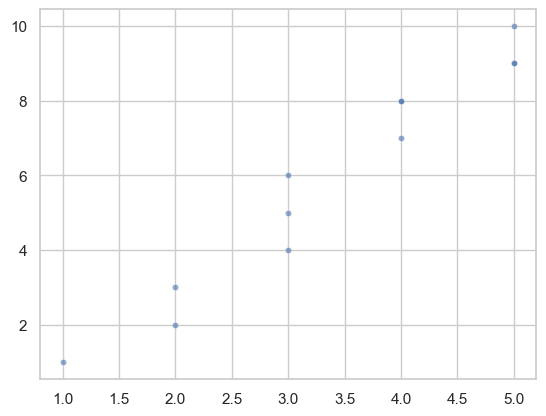

In [13]:
service_rating  = [5, 3, 4, 2, 5, 1, 4, 3, 5, 2, 4, 3]   # 1–5 stars
recommend_score = [9, 5, 7, 3, 10, 1, 8, 4, 9, 2, 8, 6]   # 1–10 NPS-style

r_pearson, _ = stats.pearsonr(service_rating, recommend_score)
print(r_pearson)
r_spearman, _ = stats.spearmanr(service_rating, recommend_score)
print(r_spearman)

plt.scatter(service_rating, recommend_score, alpha=0.6, s=20, edgecolors='white', linewidth=0.4)
plt.show()



---
## 7. QQ Plots

A QQ (Quantile-Quantile) plot checks whether your data follows a theoretical distribution — almost always the normal distribution.

**The workflow for checking normality should always follow this order:**
1. **Histogram** — get a rough visual sense of the shape
2. **Formal normality test** — get a number and p-value
3. **QQ plot** — understand *how* and *where* the distribution deviates

Each step tells you something the others don't. Never skip straight to QQ plots.


[Best YouTube video to watch to understand QQ plots](https://www.youtube.com/watch?v=X9_ISJ0YpGw)

### Demo — All three tools on four known distributions

Run this cell as-is. Four distributions are shown — for each one you get the histogram, the Shapiro-Wilk test result, and the QQ plot side by side. Study how the three tools agree and complement each other.

| Distribution | Expected histogram shape | Expected QQ plot |
|---|---|---|
| Normal | Bell curve | Points on the line |
| Right-skewed | Long right tail | Curves up at the right end |
| Heavy-tailed | Taller center, fatter tails | S-curve (both ends flare out) |
| Uniform | Flat rectangle | S-curve (both ends flare in) |

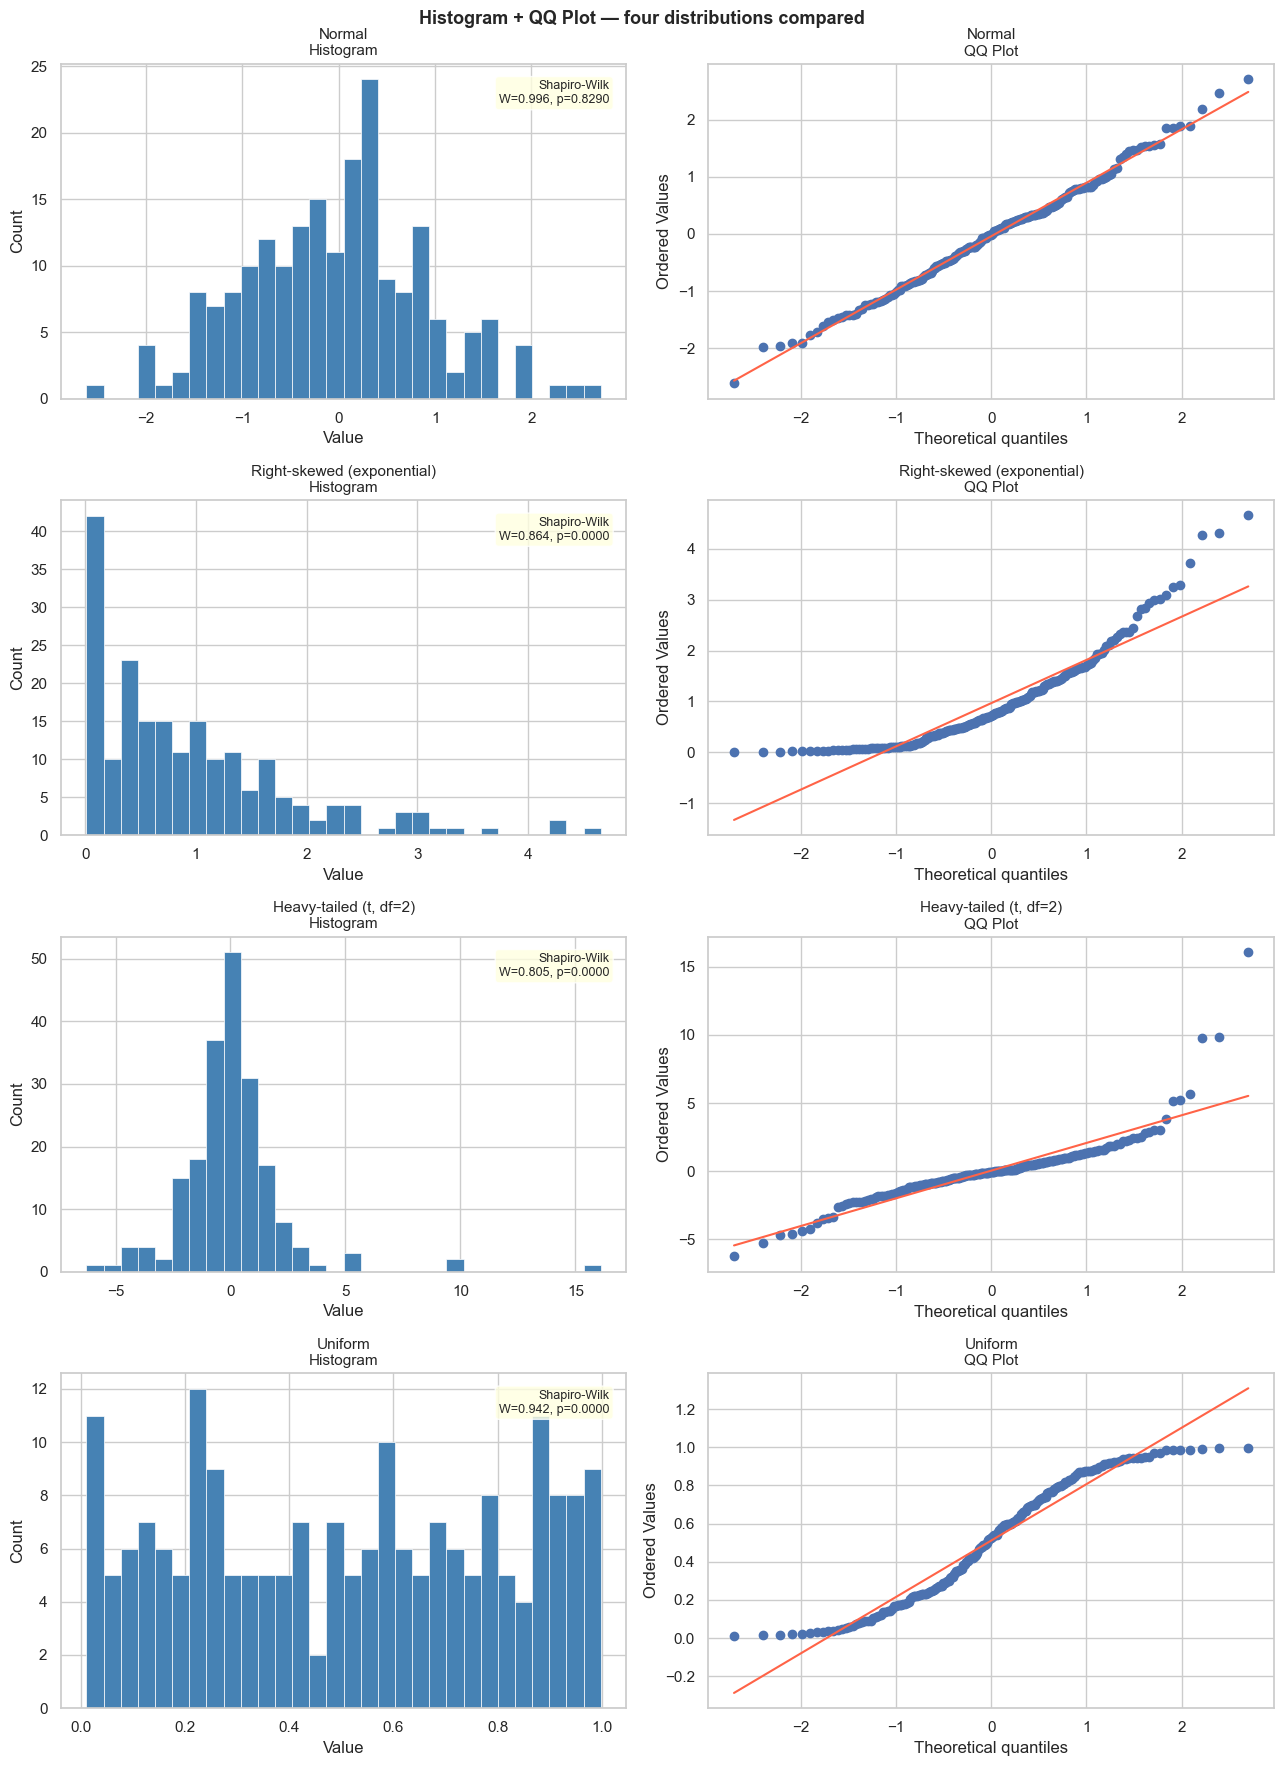

Saved to media/


In [39]:
np.random.seed(42)
n = 200

distributions = [
    (np.random.normal(0, 1, n),          'Normal'),
    (np.random.exponential(1, n),        'Right-skewed (exponential)'),
    (np.random.standard_t(df=2, size=n), 'Heavy-tailed (t, df=2)'),
    (np.random.uniform(0, 1, n),         'Uniform'),
]

fig, axes = plt.subplots(4, 2, figsize=(13, 18))

for i, (data, label) in enumerate(distributions):
    stat, p = stats.shapiro(data)

    # Left — histogram
    ax_hist = axes[i, 0]
    ax_hist.hist(data, bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
    ax_hist.set_title(f'{label}\nHistogram', fontsize=11)
    ax_hist.set_xlabel('Value')
    ax_hist.set_ylabel('Count')
    ax_hist.text(0.97, 0.95, f'Shapiro-Wilk\nW={stat:.3f}, p={p:.4f}',
                 transform=ax_hist.transAxes, ha='right', va='top',
                 fontsize=9, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    # Right — QQ plot
    ax_qq = axes[i, 1]
    stats.probplot(data, dist='norm', plot=ax_qq)
    ax_qq.set_title(f'{label}\nQQ Plot', fontsize=11)
    ax_qq.get_lines()[1].set(color='tomato', linewidth=1.5)  # reference line color

plt.suptitle('Histogram + QQ Plot — four distributions compared', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('media/qq_demo_four_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to media/')

### Task 16 — Step 1: Histogram first

You have four mystery datasets below. **Before doing any tests or QQ plots**, look at the histograms only and write your guess about each distribution's shape.

```python
np.random.seed(99)
A = np.random.normal(50, 10, 150)
B = np.random.lognormal(0, 0.8, 150)
C = np.concatenate([np.random.normal(30, 5, 75), np.random.normal(70, 5, 75)])  # bimodal
D = np.random.normal(0, 1, 150) ** 3   # cube of normals — heavy tails, slight skew
```

1. Plot all four histograms in a 2×2 grid (use 25 bins each)
2. For each one write a comment describing what you see:
   - Is it symmetric or skewed?
   - Does it have one peak or two?
   - Does it look normal?
3. Make your normality prediction **before** moving to Task 17

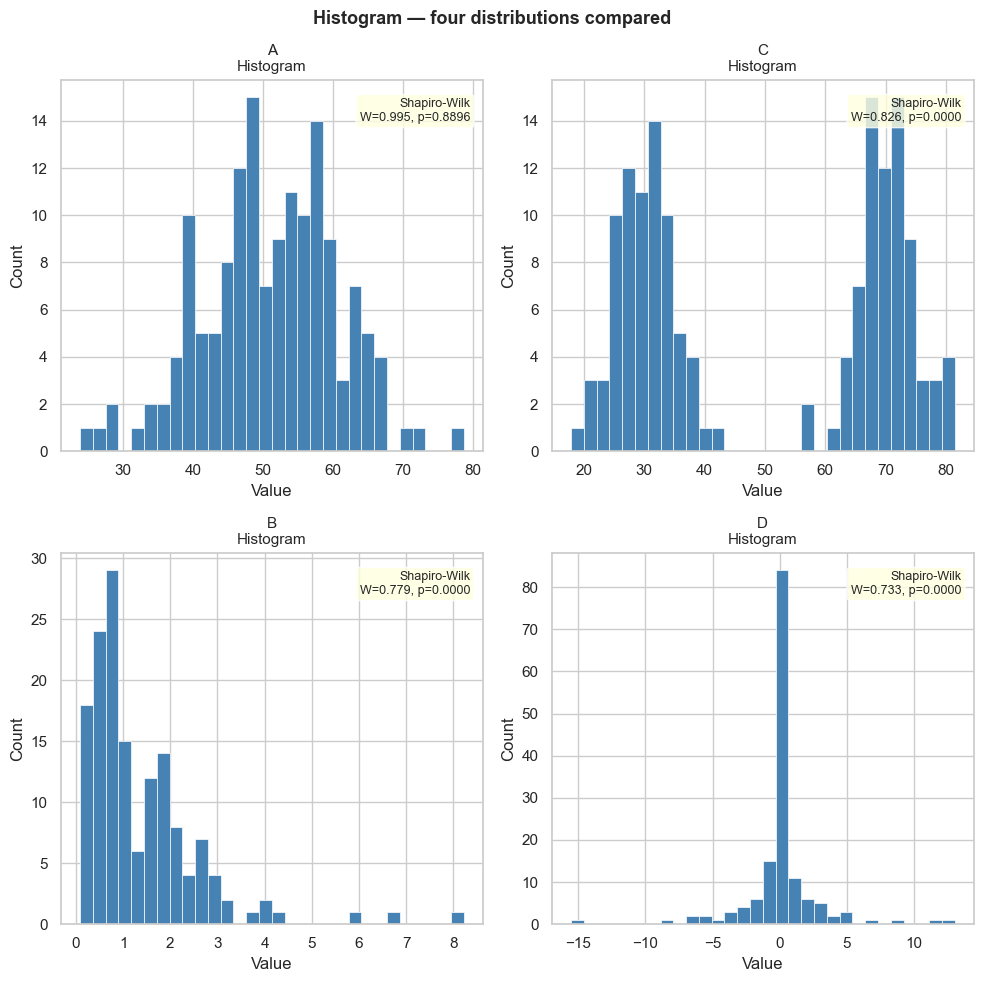

In [40]:
np.random.seed(99)
A = np.random.normal(50, 10, 150)
B = np.random.lognormal(0, 0.8, 150)
C = np.concatenate([np.random.normal(30, 5, 75), np.random.normal(70, 5, 75)])  # bimodal
D = np.random.normal(0, 1, 150) ** 3   # cube of normals — heavy tails, slight skew

distributions = [(A, 'A'), (B, 'B'), (C, 'C'), (D, 'D')]
fig, axes = plt.subplots(2, 2, figsize = (10,10))

for i, (data, label) in enumerate(distributions):
    stat, p = stats.shapiro(data)

    # Left — histogram
    if i<2:
        ax_hist = axes[i, 0]
    else: 
        ax_hist = axes[i-2, 1]
    ax_hist.hist(data, bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
    ax_hist.set_title(f'{label}\nHistogram', fontsize=11)
    ax_hist.set_xlabel('Value')
    ax_hist.set_ylabel('Count')
    ax_hist.text(0.97, 0.95, f'Shapiro-Wilk\nW={stat:.3f}, p={p:.4f}',
                 transform=ax_hist.transAxes, ha='right', va='top',
                 fontsize=9, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Histogram — four distributions compared', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Task 17 — Step 2: Formal normality tests

Using the same four datasets A, B, C, D from Task 16:

1. Run **Shapiro-Wilk** (`stats.shapiro`) on all four — print W statistic and p-value for each
2. Run **D'Agostino-Pearson** (`stats.normaltest`) on all four — print statistic and p-value
3. Interpret each result:
   - p > 0.05 → no strong evidence against normality
   - p ≤ 0.05 → evidence that the data is NOT normal
4. Did the tests agree with your histogram predictions from Task 16?
5. Were any results surprising? Write a comment

*Note: Shapiro-Wilk is better for n < 50. D'Agostino-Pearson is better for larger samples. Here n=150 — try both and compare.*

In [32]:
datasets = {'A': A, 'B': B, 'C': C, 'D': D}

print('Shapiro-Wilk Test:')
for name, data in datasets.items():
    stat, p = stats.shapiro(data)
    if p > 0.05:
        result = 'normal'
    else:
        result = 'not normal'
    print(f"{name}: W={stat:.4f}, p-value={p:.4f} → {result}")

print('\nD\'Agostino-Pearson Test:')
for name, data in datasets.items():
    stat, p = stats.normaltest(data)
    if p > 0.05:
        result = 'normal'
    else:
        result = 'not normal'
    print(f"{name}: stat={stat:.4f}, p-value={p:.4f} → {result}")

Shapiro-Wilk Test:
A: W=0.9950, p-value=0.8896 → normal
B: W=0.7787, p-value=0.0000 → not normal
C: W=0.8261, p-value=0.0000 → not normal
D: W=0.7330, p-value=0.0000 → not normal

D'Agostino-Pearson Test:
A: stat=0.8295, p-value=0.6605 → normal
B: stat=101.0805, p-value=0.0000 → not normal
C: stat=1171.0492, p-value=0.0000 → not normal
D: stat=40.7650, p-value=0.0000 → not normal


### Task 18 — Step 3: QQ plots to see exactly where and how

Now use QQ plots on the same four datasets to understand *how* each distribution deviates from normal — something the histogram and p-value alone can't tell you precisely.

1. Plot QQ plots for A, B, C, D in a 2×2 grid using `stats.probplot(data, dist='norm', plot=ax)`
2. Add the Shapiro-Wilk p-value as a text annotation on each plot (reuse values from Task 17)
3. For each dataset describe in a comment what the QQ plot shows:
   - Do points follow the line?
   - Where do they deviate — left tail, right tail, or both?
   - Does the deviation match the histogram shape you saw in Task 16?
4. Which tool — histogram, test, or QQ plot — gave you the most useful information for each dataset?

In [52]:
np.random.seed(99)
A = np.random.normal(50, 10, 150)
B = np.random.lognormal(0, 0.8, 150)
C = np.concatenate([np.random.normal(30, 5, 75), np.random.normal(70, 5, 75)])  # bimodal
D = np.random.normal(0, 1, 150) ** 3   # cube of normals — heavy tails, slight skew

b_sorted = np.sort(C)
b_quantiles = np.linspace(0, 1, len(b_sorted))
print(b_sorted[:20])
print(b_quantiles[:20])


[17.86598332 20.16833315 21.91691149 22.0258499  23.06923671 23.08239844
 23.76289256 24.43515244 24.56405617 24.97197747 25.21199387 25.33034599
 25.33186178 25.61839213 25.64791512 25.84893838 26.13176235 26.36489593
 26.48445726 26.58223569]
[0.         0.00671141 0.01342282 0.02013423 0.02684564 0.03355705
 0.04026846 0.04697987 0.05369128 0.06040268 0.06711409 0.0738255
 0.08053691 0.08724832 0.09395973 0.10067114 0.10738255 0.11409396
 0.12080537 0.12751678]


array([0.        , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
       0.55555556, 0.66666667, 0.77777778, 0.88888889, 1.        ])

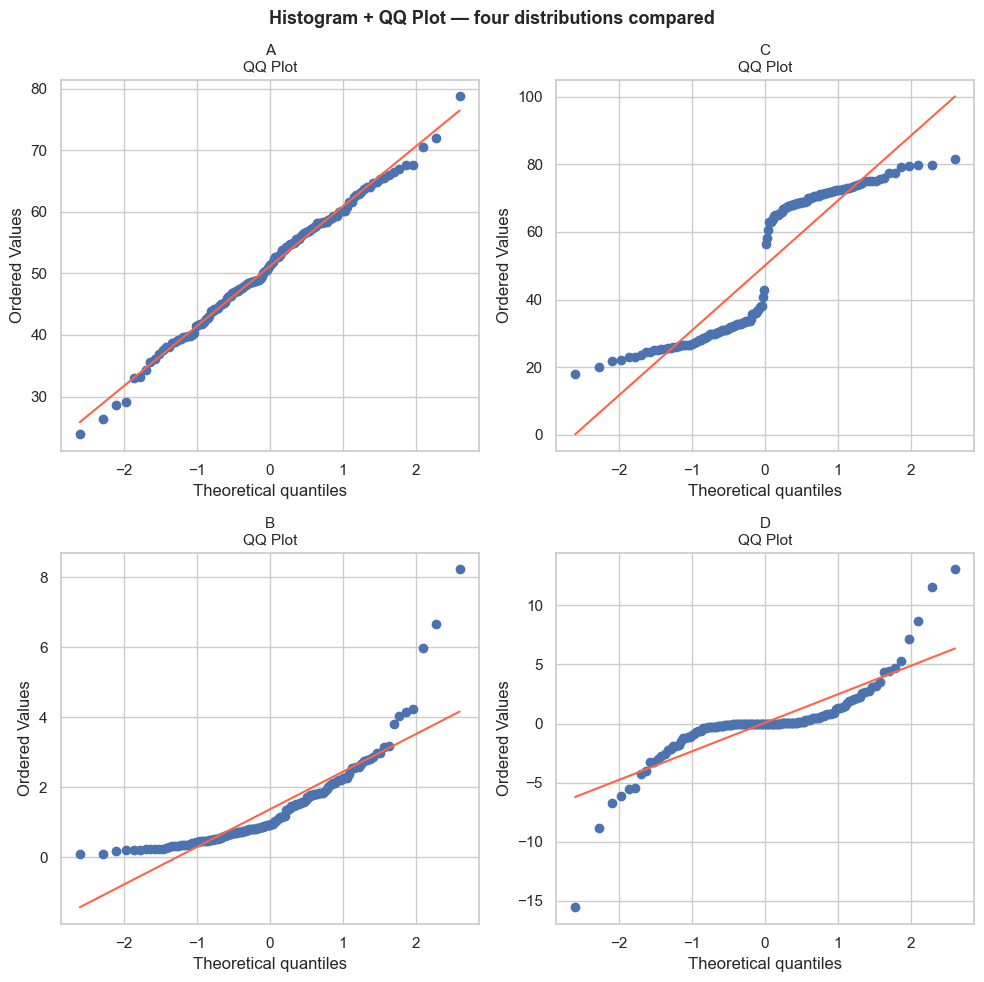

Saved to media/


In [36]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for i, (data, label) in enumerate(distributions):
    stat, p = stats.shapiro(data)


    if i<2:
        ax_qq = axes[i, 0]
    else: 
        ax_qq = axes[i-2, 1]
    stats.probplot(data, dist='norm', plot=ax_qq)
    ax_qq.set_title(f'{label}\nQQ Plot', fontsize=11)
    ax_qq.get_lines()[1].set(color='tomato', linewidth=1.5)  # reference line color

plt.suptitle('Histogram + QQ Plot — four distributions compared', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('media/qq_demo_four_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to media/')

## **More intuitive summary:**

A Q–Q plot is a way to compare your data to a theoretical distribution (usually the normal distribution) by matching values that represent the same *position* in both distributions. First, you sort your data (for example: grades like 1, 1, 2, 3, 3, 4, 10). Then you assign each data point a percentile (like 0.1, 0.2, 0.3, …), which just means “this value is at this position in the ordered data.” These percentiles are not something you compute from the normal distribution—they are just evenly spaced markers used to line up both datasets.

Next, for each percentile (p), you do two things: (1) find the value in your real data at that percentile, and (2) find the value in the normal distribution that corresponds to the same probability using the **inverse CDF** (x = F^{-1}(p)). For example, (p = 0.1) corresponds to about (x = -1.28) in a standard normal distribution. Then you plot pairs like ((-1.28, \text{your data value at 10%})). If your data is roughly normal, these points form a straight line.

Key idea:

* Percentiles (0.1, 0.2, …) are just *labels for position*, not plot values.
* X-axis = theoretical normal values (from inverse CDF)
* Y-axis = your actual data values
* A straight line means: “your data has the same shape as a normal distribution (maybe shifted or scaled)”
